# 1.Imports


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pmdarima import auto_arima
from pmdarima.model_selection import train_test_split as ts_train_test_split

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11
})


# 2. Load and Preprocessing


In [2]:
df = pd.read_csv('powerconsumption.csv', parse_dates=['Datetime'])
df.set_index('Datetime', inplace=True)
df.index.freq = None  

print(f'Shape: {df.shape}')
print(f'Período: {df.index.min()} → {df.index.max()}')
print(f'\nColumnas:\n{df.dtypes}')
df.head()

Shape: (52416, 8)
Período: 2017-01-01 00:00:00 → 2017-12-30 23:50:00

Columnas:
Temperature               float64
Humidity                  float64
WindSpeed                 float64
GeneralDiffuseFlows       float64
DiffuseFlows              float64
PowerConsumption_Zone1    float64
PowerConsumption_Zone2    float64
PowerConsumption_Zone3    float64
dtype: object


,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
Datetime,,,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [3]:
df_hourly = df.resample('H').mean()

print(f'Registros originales (10 min): {len(df):,}')
print(f'Registros horarios:            {len(df_hourly):,}')
print(f'Período: {df_hourly.index.min()} → {df_hourly.index.max()}')

series = df_hourly['PowerConsumption_Zone1']
print(f'\nSerie objetivo: PowerConsumption_Zone1')
print(f'Media: {series.mean():.1f} | Std: {series.std():.1f}')

Registros originales (10 min): 52,416
Registros horarios:            8,736
Período: 2017-01-01 00:00:00 → 2017-12-30 23:00:00

Serie objetivo: PowerConsumption_Zone1
Media: 32345.0 | Std: 7068.9


# 3.Train/Test split


In [4]:
TEST_HOURS = 168  

train = series.iloc[:-TEST_HOURS]
test  = series.iloc[-TEST_HOURS:]

print(f'Tamaño train : {len(train):,} horas  ({len(train)/24:.0f} días)')
print(f'Tamaño test  : {len(test):,} horas  ({len(test)/24:.0f} días)')
print(f'Train: {train.index.min()} → {train.index.max()}')
print(f'Test : {test.index.min()}  → {test.index.max()}')

Tamaño train : 8,568 horas  (357 días)
Tamaño test  : 168 horas  (7 días)
Train: 2017-01-01 00:00:00 → 2017-12-23 23:00:00
Test : 2017-12-24 00:00:00  → 2017-12-30 23:00:00


# 4. AutoArima without seasonality


In [5]:
model_no_seasonal = auto_arima(
    train,
    seasonal=False,         
    stepwise=True,            
    information_criterion='aic',
    error_action='ignore',
    suppress_warnings=True,
    trace=True               
)

print(f'\n✅ Mejor modelo (sin estacionalidad): ARIMA{model_no_seasonal.order}')
print(f'   AIC: {model_no_seasonal.aic():.2f}')
print(f'   BIC: {model_no_seasonal.bic():.2f}')

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=4.68 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=160312.066, Time=0.10 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=156178.503, Time=0.23 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=156472.301, Time=0.41 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=160310.066, Time=0.06 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=155653.047, Time=0.41 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=155592.989, Time=0.50 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=155395.066, Time=0.69 sec
 ARIMA(5,1,0)(0,0,0)[0] intercept   : AIC=155377.405, Time=0.84 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AIC=155377.965, Time=2.79 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=4.13 sec
 ARIMA(5,1,0)(0,0,0)[0]             : AIC=155375.405, Time=0.67 sec
 ARIMA(4,1,0)(0,0,0)[0]             : AIC=155393.065, Time=0.52 sec
 ARIMA(5,1,1)(0,0,0)[0]             : AIC=155375.951, Time=2.10 sec
 ARIMA(4,1,1)(0,0,0

In [6]:
print(model_no_seasonal.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 8568
Model:               SARIMAX(5, 1, 0)   Log Likelihood              -77681.702
Date:                Sat, 09 May 2026   AIC                         155375.405
Time:                        13:48:29   BIC                         155417.739
Sample:                    01-01-2017   HQIC                        155389.846
                         - 12-23-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7276      0.008     93.533      0.000       0.712       0.743
ar.L2         -0.2039      0.014    -14.939      0.000      -0.231      -0.177
ar.L3          0.0207      0.015      1.406      0.1

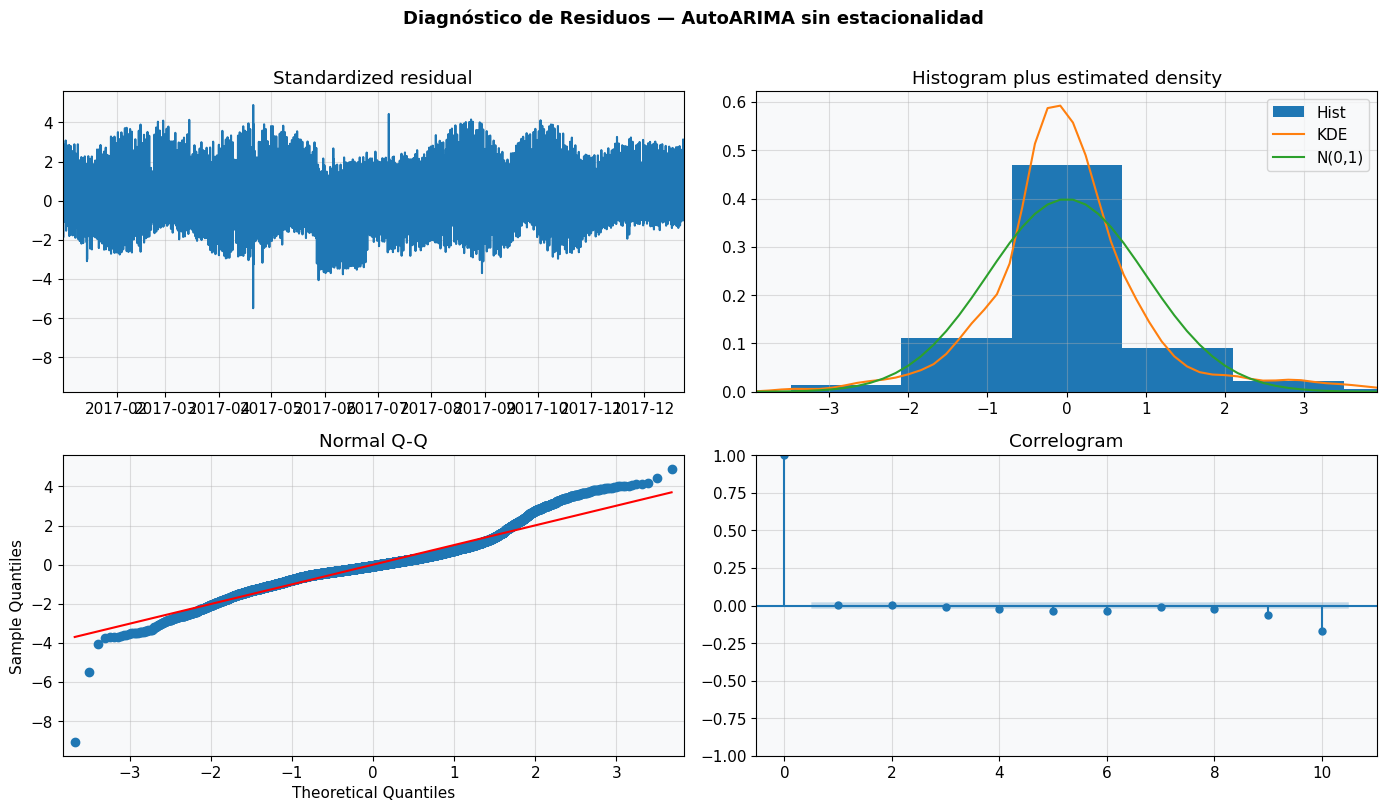

In [7]:
model_no_seasonal.plot_diagnostics(figsize=(14, 8))
plt.suptitle('Diagnóstico de Residuos — AutoARIMA sin estacionalidad', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [8]:
forecast_no_seasonal, conf_int_no_seasonal = model_no_seasonal.predict(
    n_periods=TEST_HOURS,
    return_conf_int=True,
    alpha=0.05
)

forecast_no_seasonal = pd.Series(forecast_no_seasonal, index=test.index)

# Métricas
mae_ns  = mean_absolute_error(test, forecast_no_seasonal)
rmse_ns = np.sqrt(mean_squared_error(test, forecast_no_seasonal))
mape_ns = np.mean(np.abs((test.values - forecast_no_seasonal.values) / test.values)) * 100

print('📈 Resultados — AutoARIMA SIN Estacionalidad')
print(f'   Modelo : ARIMA{model_no_seasonal.order}')
print(f'   MAE    : {mae_ns:.2f} kW')
print(f'   RMSE   : {rmse_ns:.2f} kW')
print(f'   MAPE   : {mape_ns:.2f} %')

📈 Resultados — AutoARIMA SIN Estacionalidad
   Modelo : ARIMA(5, 1, 0)
   MAE    : 5383.00 kW
   RMSE   : 6312.83 kW
   MAPE   : 20.05 %


# 5. AutoArima with seasonality

In [9]:
train_seasonal = train[-2160:]  # 90 días x 24 horas = 2160 observaciones hacemos con observaciones de 90 dias porque si utilizamos el año da memory error
#Copnsideramos que un periodo de 90 dias sigue siendo util para conseguir ver un patron o tendencia en el uso de energia diario

print('🔍 Ajustando AutoARIMA CON estacionalidad (m=24)...')
print(f'   Usando train reducido: {len(train_seasonal)} horas ({len(train_seasonal)//24} días)')
print('   (puede tardar varios minutos)\n')

model_seasonal = auto_arima(
    train_seasonal,
    seasonal=True,            # Con componente estacional
    m=24,                     # Ciclo diario: 24 horas
    stepwise=True,
    information_criterion='aic',
    error_action='ignore',
    suppress_warnings=True,
    trace=True
)

print(f'\n✅ Mejor modelo (con estacionalidad): SARIMA{model_seasonal.order}x{model_seasonal.seasonal_order}')
print(f'   AIC: {model_seasonal.aic():.2f}')
print(f'   BIC: {model_seasonal.bic():.2f}')

🔍 Ajustando AutoARIMA CON estacionalidad (m=24)...
   Usando train reducido: 2160 horas (90 días)
   (puede tardar varios minutos)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[24] intercept   : AIC=inf, Time=5.43 sec
 ARIMA(0,1,0)(0,0,0)[24] intercept   : AIC=39912.939, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[24] intercept   : AIC=inf, Time=nan sec
 ARIMA(0,1,1)(0,0,1)[24] intercept   : AIC=37466.563, Time=2.21 sec
 ARIMA(0,1,0)(0,0,0)[24]             : AIC=39910.940, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[24] intercept   : AIC=38968.823, Time=0.09 sec
 ARIMA(0,1,1)(1,0,1)[24] intercept   : AIC=34294.829, Time=5.69 sec
 ARIMA(0,1,1)(1,0,0)[24] intercept   : AIC=35057.969, Time=2.41 sec
 ARIMA(0,1,1)(2,0,1)[24] intercept   : AIC=inf, Time=18.90 sec
 ARIMA(0,1,1)(1,0,2)[24] intercept   : AIC=inf, Time=26.68 sec
 ARIMA(0,1,1)(0,0,2)[24] intercept   : AIC=36664.311, Time=11.43 sec
 ARIMA(0,1,1)(2,0,0)[24] intercept   : AIC=34667.880, Time=12.70 sec
 ARIMA(0,1,1)(2,0,2)[24] inter

In [10]:
print(model_seasonal.summary())

                                        SARIMAX Results                                        
Dep. Variable:                                       y   No. Observations:                 2160
Model:             SARIMAX(0, 1, 4)x(1, 0, [1, 2], 24)   Log Likelihood              -17110.115
Date:                                 Sat, 09 May 2026   AIC                          34236.230
Time:                                         14:02:10   BIC                          34281.649
Sample:                                     09-25-2017   HQIC                         34252.843
                                          - 12-23-2017                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.1764      0.009     19.041      0.000       0.158       0

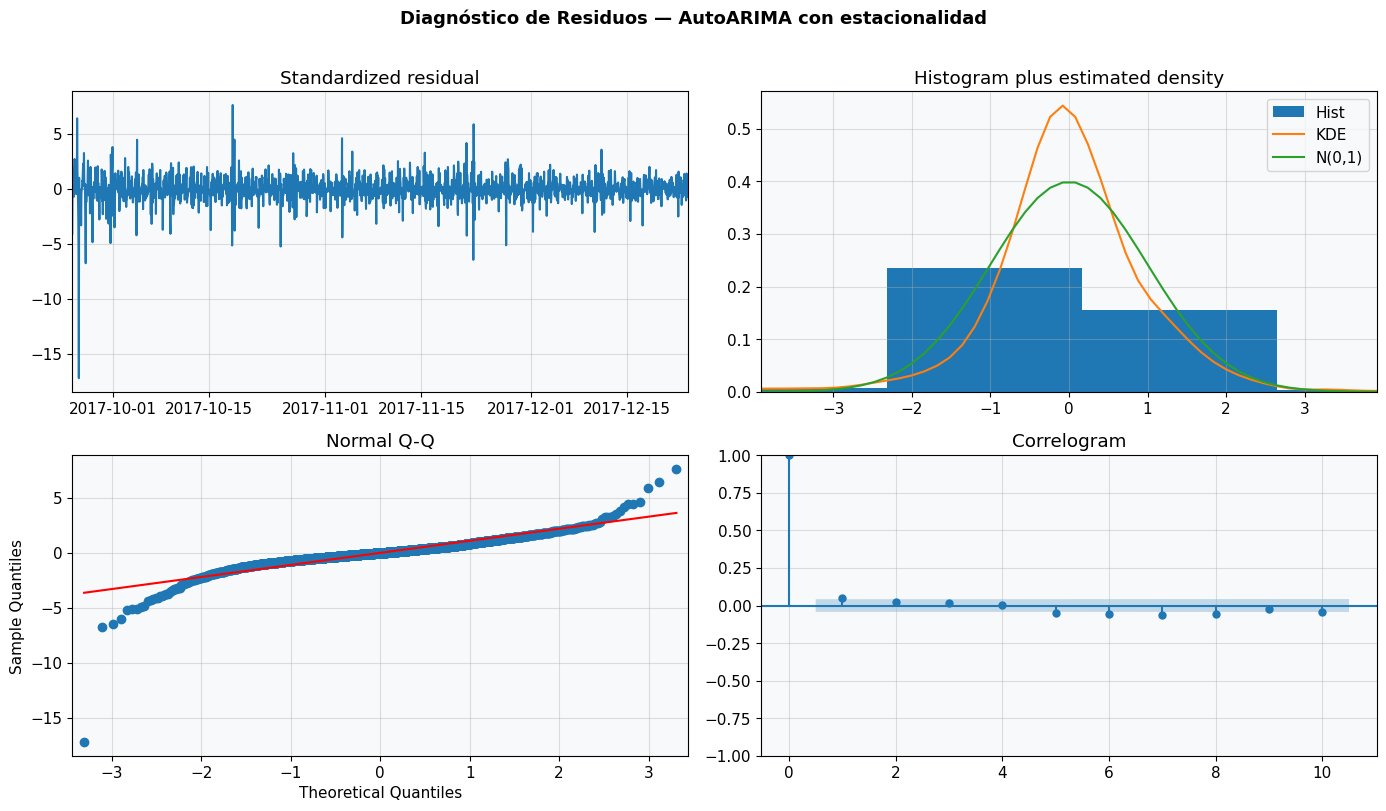

In [11]:
model_seasonal.plot_diagnostics(figsize=(14, 8))
plt.suptitle('Diagnóstico de Residuos — AutoARIMA con estacionalidad', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [12]:
forecast_seasonal, conf_int_seasonal = model_seasonal.predict(
    n_periods=TEST_HOURS,
    return_conf_int=True,
    alpha=0.05
)

forecast_seasonal = pd.Series(forecast_seasonal, index=test.index)

# Métricas
mae_s  = mean_absolute_error(test, forecast_seasonal)
rmse_s = np.sqrt(mean_squared_error(test, forecast_seasonal))
mape_s = np.mean(np.abs((test.values - forecast_seasonal.values) / test.values)) * 100

print('📈 Resultados — AutoARIMA CON Estacionalidad')
print(f'   Modelo : SARIMA{model_seasonal.order}x{model_seasonal.seasonal_order}')
print(f'   MAE    : {mae_s:.2f} kW')
print(f'   RMSE   : {rmse_s:.2f} kW')
print(f'   MAPE   : {mape_s:.2f} %')

📈 Resultados — AutoARIMA CON Estacionalidad
   Modelo : SARIMA(0, 1, 4)x(1, 0, 2, 24)
   MAE    : 1440.52 kW
   RMSE   : 1779.06 kW
   MAPE   : 5.45 %


# 6. Visual Comparison

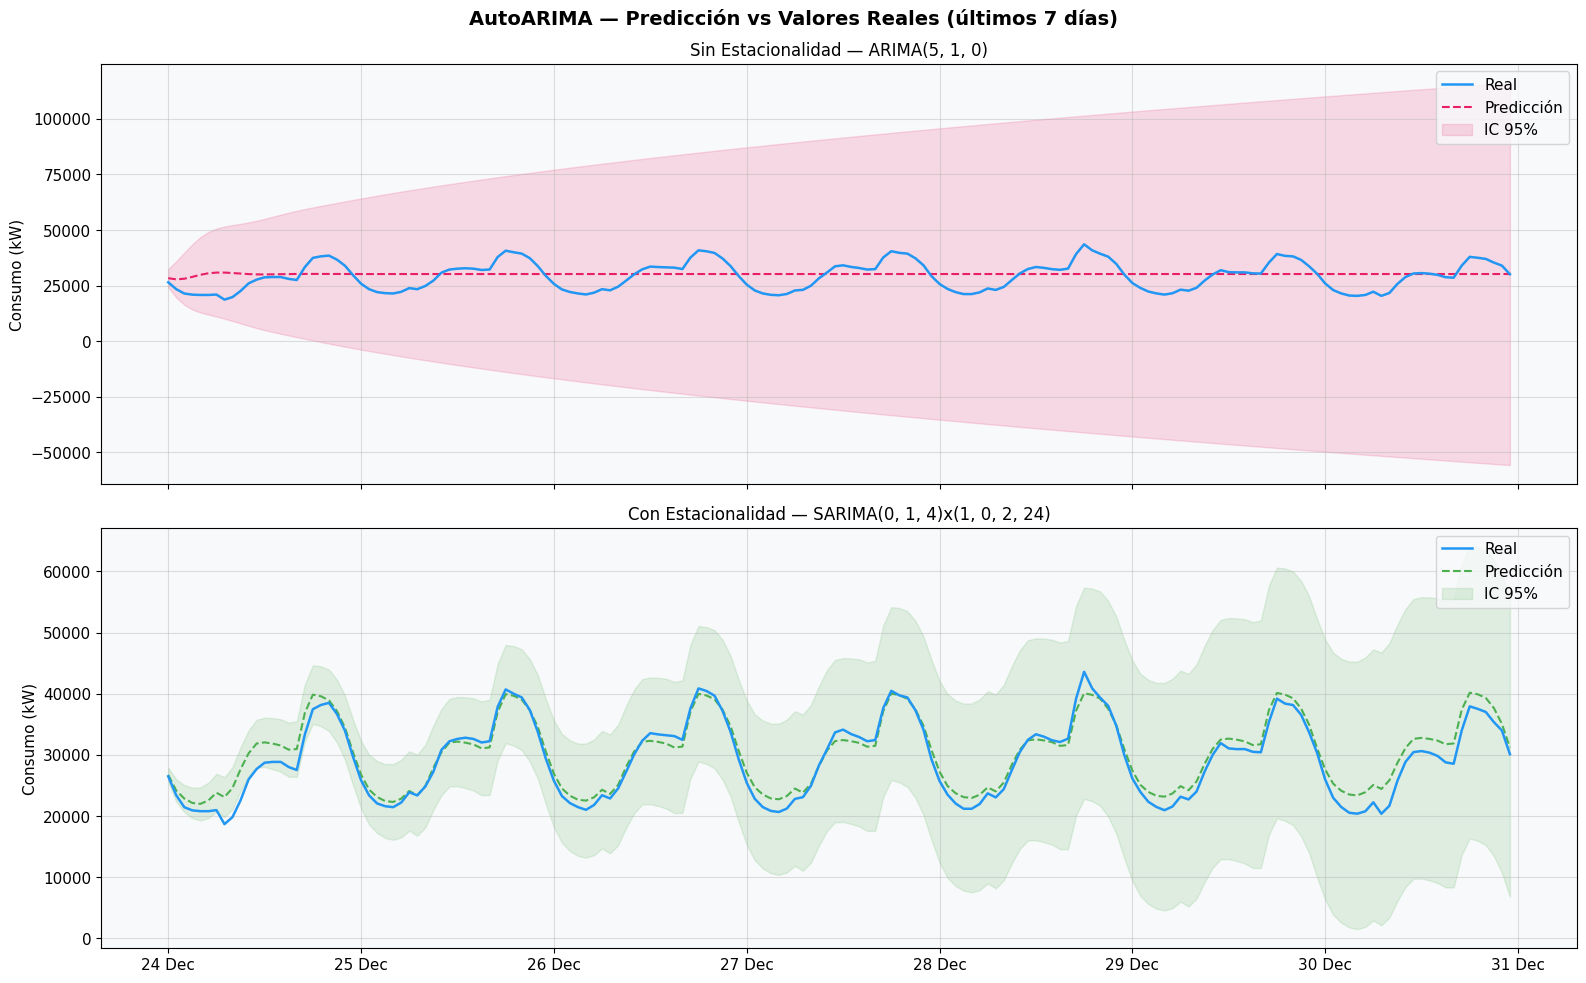

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle('AutoARIMA — Predicción vs Valores Reales (últimos 7 días)', fontsize=14, fontweight='bold')

for ax, (fc, ci, title, color) in zip(axes, [
    (forecast_no_seasonal, conf_int_no_seasonal,
     f'Sin Estacionalidad — ARIMA{model_no_seasonal.order}', '#E91E63'),
    (forecast_seasonal, conf_int_seasonal,
     f'Con Estacionalidad — SARIMA{model_seasonal.order}x{model_seasonal.seasonal_order}', '#4CAF50'),
]):
    ax.plot(test.index, test.values, color='#2196F3', linewidth=1.8, label='Real', zorder=3)
    ax.plot(test.index, fc.values,   color=color,    linewidth=1.5, linestyle='--', label='Predicción', zorder=2)
    ax.fill_between(
        test.index,
        ci[:, 0], ci[:, 1],
        color=color, alpha=0.15, label='IC 95%'
    )
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Consumo (kW)')
    ax.legend(loc='upper right')
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

plt.tight_layout()
plt.show()

In [14]:

results = pd.DataFrame({
    'Modelo': [
        f'ARIMA{model_no_seasonal.order}\n(sin estacionalidad)',
        f'SARIMA{model_seasonal.order}x{model_seasonal.seasonal_order}\n(con estacionalidad m=24)'
    ],
    'AIC': [model_no_seasonal.aic(), model_seasonal.aic()],
    'BIC': [model_no_seasonal.bic(), model_seasonal.bic()],
    'MAE':  [mae_ns,  mae_s],
    'RMSE': [rmse_ns, rmse_s],
    'MAPE (%)': [mape_ns, mape_s]
})

print('=' * 70)
print('TABLA COMPARATIVA — AutoARIMA con y sin estacionalidad')
print('=' * 70)
print(results.to_string(index=False, float_format='{:.2f}'.format))
print('=' * 70)

# Resaltar mejor modelo
mejor_mae = 'CON estacionalidad' if mae_s < mae_ns else 'SIN estacionalidad'
mejor_rmse = 'CON estacionalidad' if rmse_s < rmse_ns else 'SIN estacionalidad'
print(f'\n🏆 Menor MAE  → {mejor_mae}')
print(f'🏆 Menor RMSE → {mejor_rmse}')

TABLA COMPARATIVA — AutoARIMA con y sin estacionalidad
                                                  Modelo       AIC       BIC     MAE    RMSE  MAPE (%)
                    ARIMA(5, 1, 0)\n(sin estacionalidad) 155375.40 155417.74 5383.00 6312.83     20.05
SARIMA(0, 1, 4)x(1, 0, 2, 24)\n(con estacionalidad m=24)  34236.23  34281.65 1440.52 1779.06      5.45

🏆 Menor MAE  → CON estacionalidad
🏆 Menor RMSE → CON estacionalidad


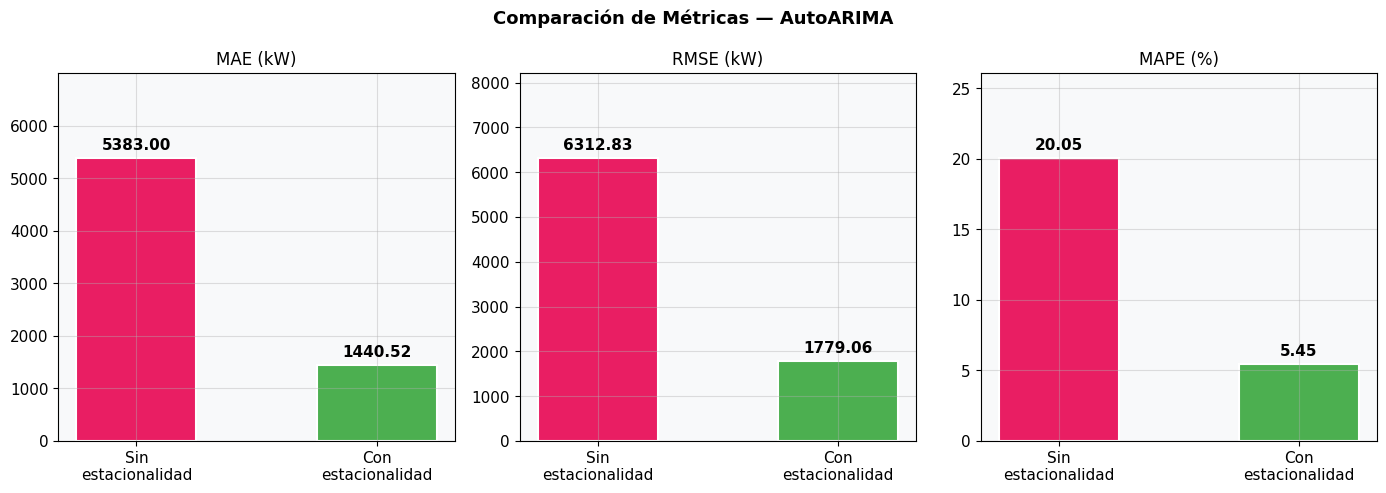

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Comparación de Métricas — AutoARIMA', fontsize=13, fontweight='bold')

labels = ['Sin\nestacionalidad', 'Con\nestacionalidad']
colors = ['#E91E63', '#4CAF50']

for ax, (metric_vals, metric_name) in zip(axes, [
    ([mae_ns, mae_s],   'MAE (kW)'),
    ([rmse_ns, rmse_s], 'RMSE (kW)'),
    ([mape_ns, mape_s], 'MAPE (%)'),
]):
    bars = ax.bar(labels, metric_vals, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
    ax.set_title(metric_name, fontsize=12)
    ax.set_ylim(0, max(metric_vals) * 1.3)
    for bar, val in zip(bars, metric_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(metric_vals)*0.02,
                f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()